# ✈️ Analysis of Emirates Customer Sentiment & Campaign Effectiveness

**Objective:** Evaluate Emirates' competitive position against Qatar Airways and Etihad Airways using customer review NLP, identify key praise and pain points, and analyse search trend & sponsorship effectiveness from 2022–2025.

---
**Sections:**
1. Competitive Sentiment & Service Analysis (Emirates vs Qatar vs Etihad)
2. Emirates — Top 5 Praises & Complaints
3. Emirates Fleet Analysis (as of March 2026)
4. Emirates Top Routes To/From DXB
5. Search Trend & Sponsorship Analysis (2022–2025)

In [4]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(".")), "src"))

import warnings
warnings.filterwarnings("ignore")

import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 130
matplotlib.rcParams["font.family"] = "DejaVu Sans"

# ── Resolve project root and CSV path ────────────────────────────────────────
# The notebook lives in notebooks/, so ".." goes up to the project root
PROJECT_ROOT = pathlib.Path(os.path.abspath(".."))
RAW_CSV = str(PROJECT_ROOT / "data" / "raw" / "AirlineReviews.csv")
print(f"📂 Project root : {PROJECT_ROOT}")
print(f"📄 Reviews CSV  : {RAW_CSV}")

# Verify the file actually exists before running the pipeline
if not pathlib.Path(RAW_CSV).exists():
    raise FileNotFoundError(f"❌ Could not find: {RAW_CSV}\nCheck your data/raw/ folder.")
print("✅ CSV file found.\n")

# ── Run the full pipeline ────────────────────────────────────────────────────
from pipeline import run_review_pipeline, run_scraping_pipeline

print("⏳ Running review pipeline (NLP scoring + model evaluation)...")
print("   This may take 5–15 min on first run while RoBERTa model downloads.")
review_out = run_review_pipeline(RAW_CSV)
print(f"\n✅ Review pipeline complete. Winner model: {review_out.winner.upper()}")

print("\n⏳ Running scraping pipeline (fleet, routes, sponsorships)...")
scrape_out = run_scraping_pipeline()
print("✅ Scraping pipeline complete.")

# ── Convenience aliases ──────────────────────────────────────────────────────
df_rivals    = review_out.df_rivals
df_emirates  = review_out.df_emirates
praise_df    = review_out.praise_df
complaint_df = review_out.complaint_df
winner       = review_out.winner

fleet_df    = scrape_out.fleet_df
routes_df   = scrape_out.routes_df
trends_df   = scrape_out.trends_df
ek_sponsors = scrape_out.ek_sponsors
qr_sponsors = scrape_out.qr_sponsors

print(f"\n📊 Dataset summary:")
print(f"   Total rival reviews loaded : {len(df_rivals):,}")
print(f"   Emirates reviews           : {len(df_emirates):,}")
print(f"   Winning NLP model          : {winner.upper()}")

[INFO] pipeline — ============================================================
[INFO] pipeline — STEP 1: Loading and preprocessing reviews
[INFO] pipeline — ============================================================


📂 Project root : c:\repos\Analysis-of-Emirates-Customer-Sentiment-and-Campaign-Effectiveness
📄 Reviews CSV  : c:\repos\Analysis-of-Emirates-Customer-Sentiment-and-Campaign-Effectiveness\data\raw\AirlineReviews.csv
✅ CSV file found.

⏳ Running review pipeline (NLP scoring + model evaluation)...
   This may take 5–15 min on first run while RoBERTa model downloads.


[INFO] data.load — Loaded 129455 reviews from AirlineReviews.csv
[INFO] data.load — Filtered to 6126 reviews for ['Emirates', 'Qatar Airways', 'Etihad Airways']
[INFO] data.load — Emirates subset: 2254 reviews
[INFO] pipeline — ============================================================
[INFO] pipeline — STEP 2: Sentiment scoring (VADER)
[INFO] pipeline — ============================================================
[INFO] pipeline — ============================================================
[INFO] pipeline — STEP 3: Sentiment scoring (Pre-trained RoBERTa)
[INFO] pipeline — ============================================================
[INFO] models.sentiment_pretrained — Loading pre-trained model: cardiffnlp/twitter-roberta-base-sentiment-latest
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 53425.55it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
----------------------


✅ Review pipeline complete. Winner model: PRETRAINED

⏳ Running scraping pipeline (fleet, routes, sponsorships)...


[INFO] scraping.search_trends — Generating trend proxy from sponsorship density for 'Emirates airline'...
[INFO] scraping.search_trends — Loaded 18 records from emirates_sponsorships.json
[INFO] scraping.search_trends — Attempting to fetch trends page for 'Qatar Airways'...
[INFO] scraping.search_trends — Generating trend proxy from sponsorship density for 'Qatar Airways'...
[INFO] scraping.search_trends — Loaded 14 records from qatar_sponsorships.json
[INFO] scraping.search_trends — Combined trends data: 48 months
[INFO] scraping.search_trends — Loaded 18 records from emirates_sponsorships.json
[INFO] scraping.search_trends — Loaded 14 records from qatar_sponsorships.json
[INFO] pipeline — ============================================================
[INFO] pipeline — SCRAPING STEP 2: Emirates Fleet Analysis
[INFO] pipeline — ============================================================
[INFO] scraping.fleet_scraper — Scraping Emirates fleet data from Wikipedia...
[WARNING] scraping.fle

✅ Scraping pipeline complete.

📊 Dataset summary:
   Total rival reviews loaded : 6,126
   Emirates reviews           : 2,254
   Winning NLP model          : PRETRAINED


---
## 📊 Section 1: Competitive Analysis — Emirates vs Qatar Airways vs Etihad Airways

We compare:
- Overall sentiment score distributions
- Average service sub-ratings across 5 dimensions
- How customer sentiment has evolved month-by-month since 2015

Sentiment model used: PRETRAINED
Sentiment score range: -1.0 (very negative) to +1.0 (very positive)

── Sentiment Score Summary ──


,Mean Score,Median Score,Std Dev,No. of Reviews
AirlineName,,,,
Emirates,-0.045,0.0,0.925,2254
Etihad Airways,-0.357,-1.0,0.846,1676
Qatar Airways,0.390,1.0,0.832,2196


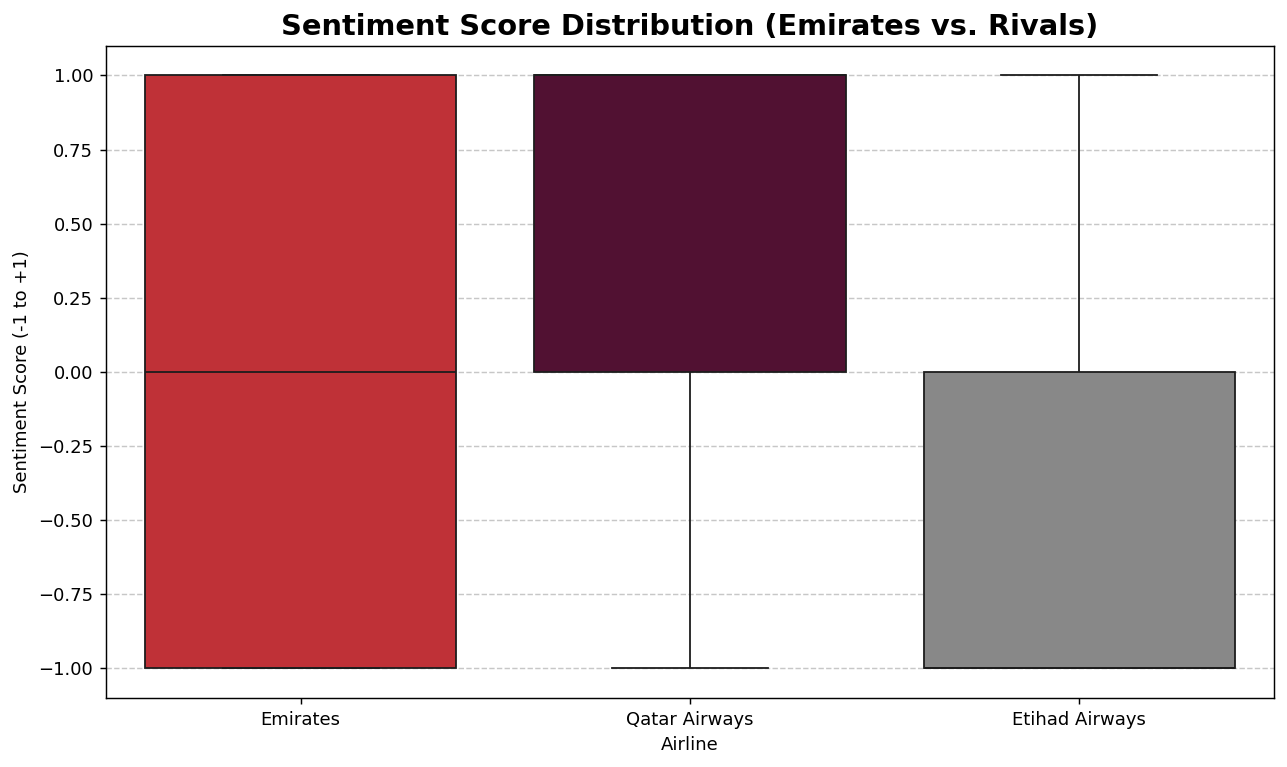

In [5]:
from viz.plots import plot_sentiment_distribution

print(f"Sentiment model used: {winner.upper()}")
print(f"Sentiment score range: -1.0 (very negative) to +1.0 (very positive)\n")

# Summary table first
summary = (
    df_rivals.groupby("AirlineName")["sentiment_score"]
    .agg(["mean", "median", "std", "count"])
    .rename(columns={"mean": "Mean Score", "median": "Median Score",
                     "std": "Std Dev", "count": "No. of Reviews"})
    .round(3)
)
print("── Sentiment Score Summary ──")
display(summary)

# Boxplot
plot_sentiment_distribution(df_rivals)

In [7]:
from viz.plots import plot_sentiment_distribution

print(f"Sentiment model used: {winner.upper()}")
print(f"Sentiment score range: -1.0 (very negative) to +1.0 (very positive)\n")

# Summary table first
summary = (
    df_rivals.groupby("AirlineName")["sentiment_score"]
    .agg(["mean", "median", "std", "count"])
    .rename(columns={"mean": "Mean Score", "median": "Median Score",
                     "std": "Std Dev", "count": "No. of Reviews"})
    .round(3)
)
print("── Sentiment Score Summary ──")
display(summary)


Sentiment model used: PRETRAINED
Sentiment score range: -1.0 (very negative) to +1.0 (very positive)

── Sentiment Score Summary ──


,Mean Score,Median Score,Std Dev,No. of Reviews
AirlineName,,,,
Emirates,-0.045,0.0,0.925,2254
Etihad Airways,-0.357,-1.0,0.846,1676
Qatar Airways,0.390,1.0,0.832,2196


---
## 💬 Section 2: Emirates — Top 5 Praises & Complaints

Reviews classified as **positive** by the winning model are analysed for praise themes.  
Reviews classified as **negative** are analysed for complaint themes.  
Categories are ranked by **TF-IDF weighted term frequency** — purely data-driven, no manual guessing.

Analysing 916 positive Emirates reviews...

── Top 5 Praise Categories ──


' rank           category  weight\n    1 Cabin Crew Service  0.3028\n    2    Food & Beverage  0.2763\n    3 Overall Experience  0.2540\n    4  Lounge Experience  0.2337\n    5       Seat Comfort  0.2308'

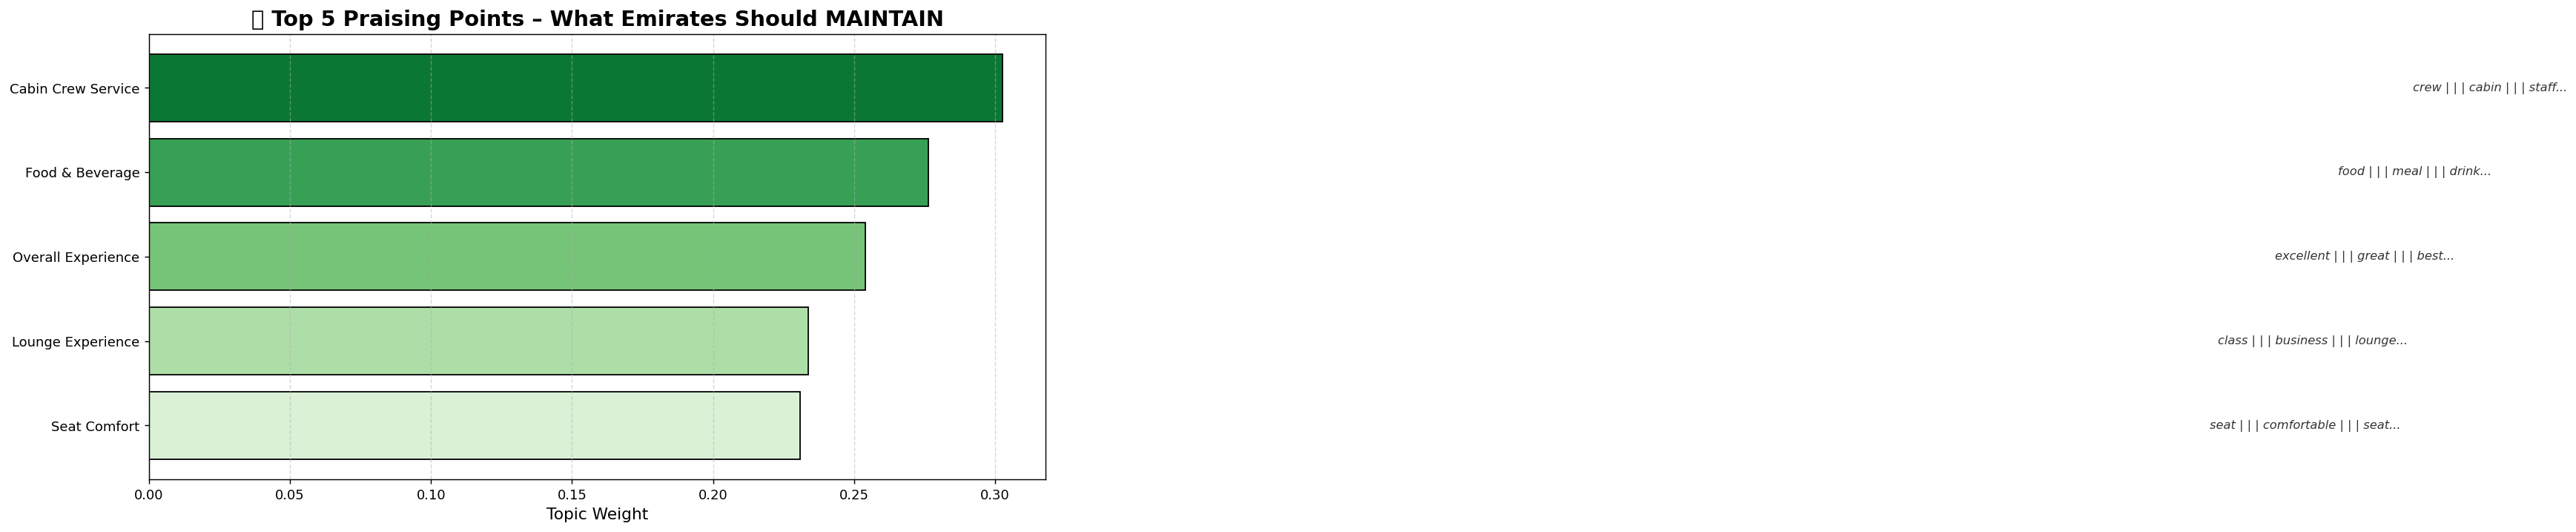

In [8]:
from viz.plots import plot_top_praises

print(f"Analysing {len(df_emirates[df_emirates['sentiment_label']=='positive']):,} "
      f"positive Emirates reviews...\n")

print("── Top 5 Praise Categories ──")
display(praise_df[["rank", "category", "weight"]].to_string(index=False))
print()

plot_top_praises(praise_df)

Analysing 1,018 negative Emirates reviews...

── Top 5 Complaint Categories ──


' rank                      category  weight\n    1 Flight Delays & Cancellations  0.2051\n    2               Seat Discomfort  0.0995\n    3         Poor Customer Service  0.0853\n    4                Baggage Issues  0.0612\n    5         Transfer & Connection  0.0515'

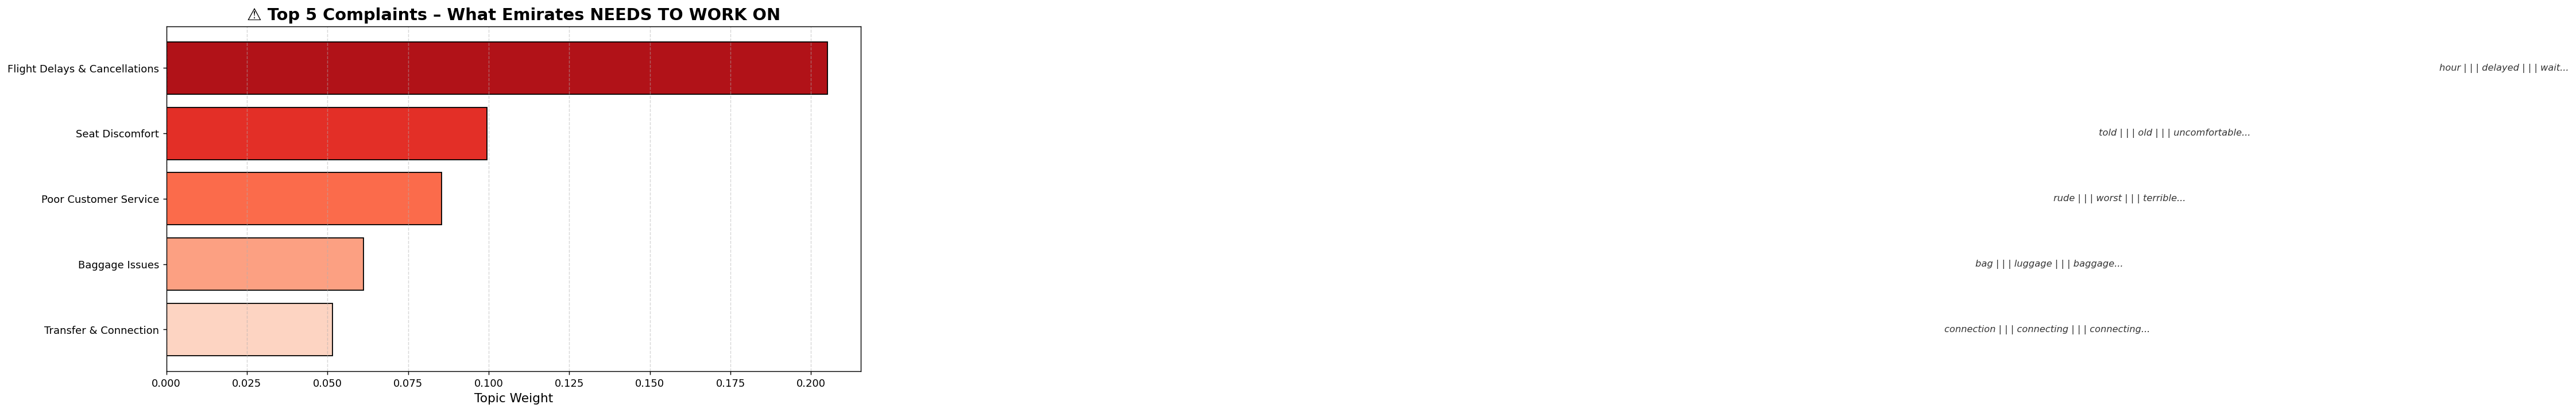

In [9]:
from viz.plots import plot_top_complaints

print(f"Analysing {len(df_emirates[df_emirates['sentiment_label']=='negative']):,} "
      f"negative Emirates reviews...\n")

print("── Top 5 Complaint Categories ──")
display(complaint_df[["rank", "category", "weight"]].to_string(index=False))
print()

plot_top_complaints(complaint_df)

---
## ✈️ Section 3: Emirates Fleet Analysis (as of March 2026)

Emirates operates one of the world's most modern and largest commercial fleets.  
This section examines the **current active fleet composition** and the **massive order book** that signals future expansion strategy.

── Emirates Fleet Summary ──


,aircraft,in_service,orders,passengers,notes
0,Airbus A380-800,116,0,489-615,World's largest A380 fleet operator
1,Boeing 777-300ER,133,0,354-428,Backbone of long-haul fleet
2,Boeing 777-200LR,10,0,266,Ultra-long-range variant
3,Boeing 777-F,11,0,Cargo,Emirates SkyCargo dedicated
4,Boeing 777-9,0,205,~400 (est.),Largest 777X order globally; deliveries starti...
5,Boeing 787-9 Dreamliner,0,35,~300 (est.),First Dreamliner order by Emirates (2024)
6,Airbus A350-900,5,60,312 (est.),New type for Emirates; deliveries began late 2024



📊 Total aircraft in service : 275
📦 Total on order            : 300
🔮 Future fleet size (est.)  : 575


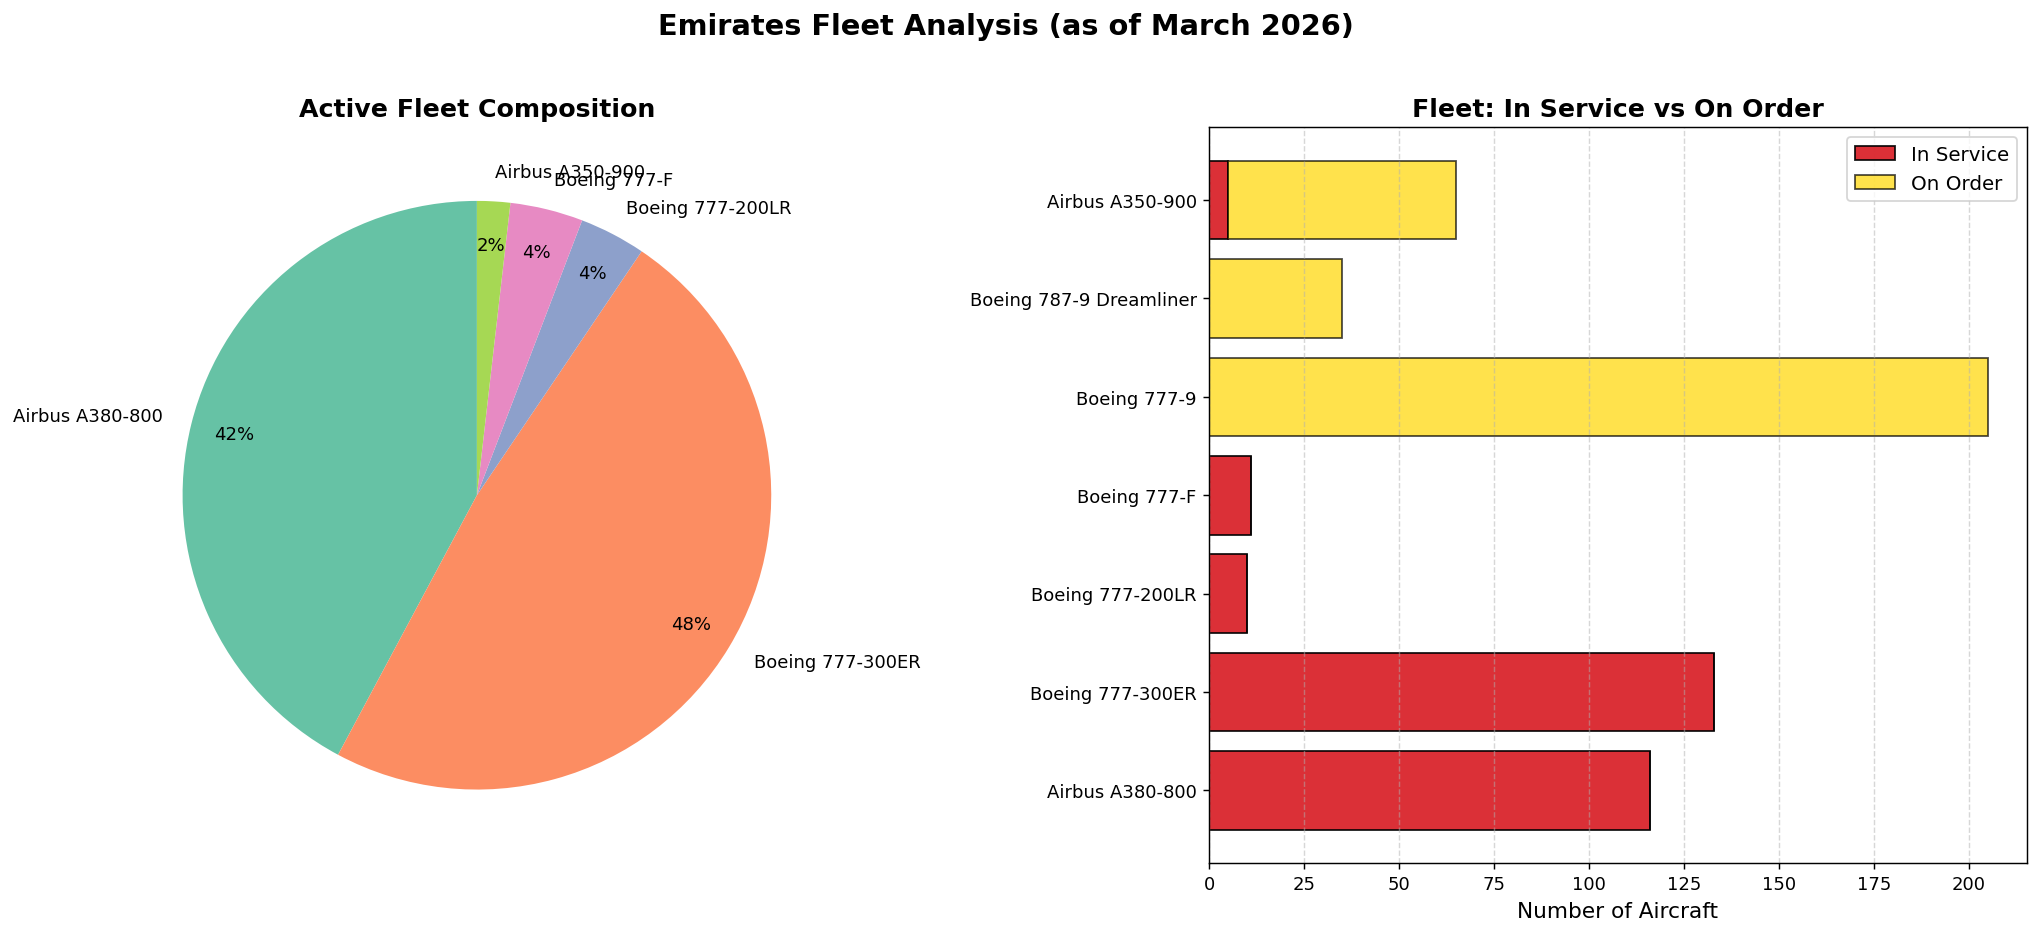

In [10]:
from viz.plots import plot_fleet_composition

# Display raw fleet table
fleet_display = fleet_df.copy()
fleet_display["in_service"] = pd.to_numeric(fleet_display["in_service"], errors="coerce").fillna(0).astype(int)
fleet_display["orders"]     = pd.to_numeric(fleet_display["orders"],     errors="coerce").fillna(0).astype(int)

print("── Emirates Fleet Summary ──")
display(fleet_display[["aircraft", "in_service", "orders", "passengers", "notes"]])

total_active = fleet_display["in_service"].sum()
total_orders = fleet_display["orders"].sum()
print(f"\n📊 Total aircraft in service : {total_active}")
print(f"📦 Total on order            : {total_orders}")
print(f"🔮 Future fleet size (est.)  : {total_active + total_orders}")

plot_fleet_composition(fleet_df)

---
## 🗺️ Section 4: Emirates Top Routes To & From Dubai (DXB)

Dubai International Airport (DXB) is the world's busiest international airport by passenger traffic.  
The routes below represent Emirates' highest-frequency corridors — combining commercial demand, strategic hub connectivity, and tourism flows.

── Top 5 Routes FROM DXB ──


,rank,route,daily_flights,aircraft,distance_km,notes
0,1,DXB → LHR (London Heathrow),6,A380 / 777-300ER,5467,Highest frequency Emirates route globally
1,2,DXB → BKK (Bangkok Suvarnabhumi),4,A380 / 777-300ER,4924,Major Southeast Asia gateway
2,3,DXB → SIN (Singapore Changi),3,A380,5844,Key hub-to-hub route
3,4,DXB → JFK (New York JFK),3,A380,11023,Flagship US route
4,5,DXB → BOM (Mumbai),4,777-300ER,1928,Largest Indian market route



── Top 5 Routes TO DXB ──


,rank,route,daily_flights,aircraft,distance_km,notes
0,1,LHR (London Heathrow) → DXB,6,A380 / 777-300ER,5467,Highest inbound frequency
1,2,BOM (Mumbai) → DXB,4,777-300ER,1928,High demand expatriate corridor
2,3,BKK (Bangkok) → DXB,4,A380 / 777-300ER,4924,Major tourism & business corridor
3,4,SYD (Sydney) → DXB,3,A380,12045,Kangaroo route anchor
4,5,JFK (New York) → DXB,3,A380,11023,Premium transatlantic demand


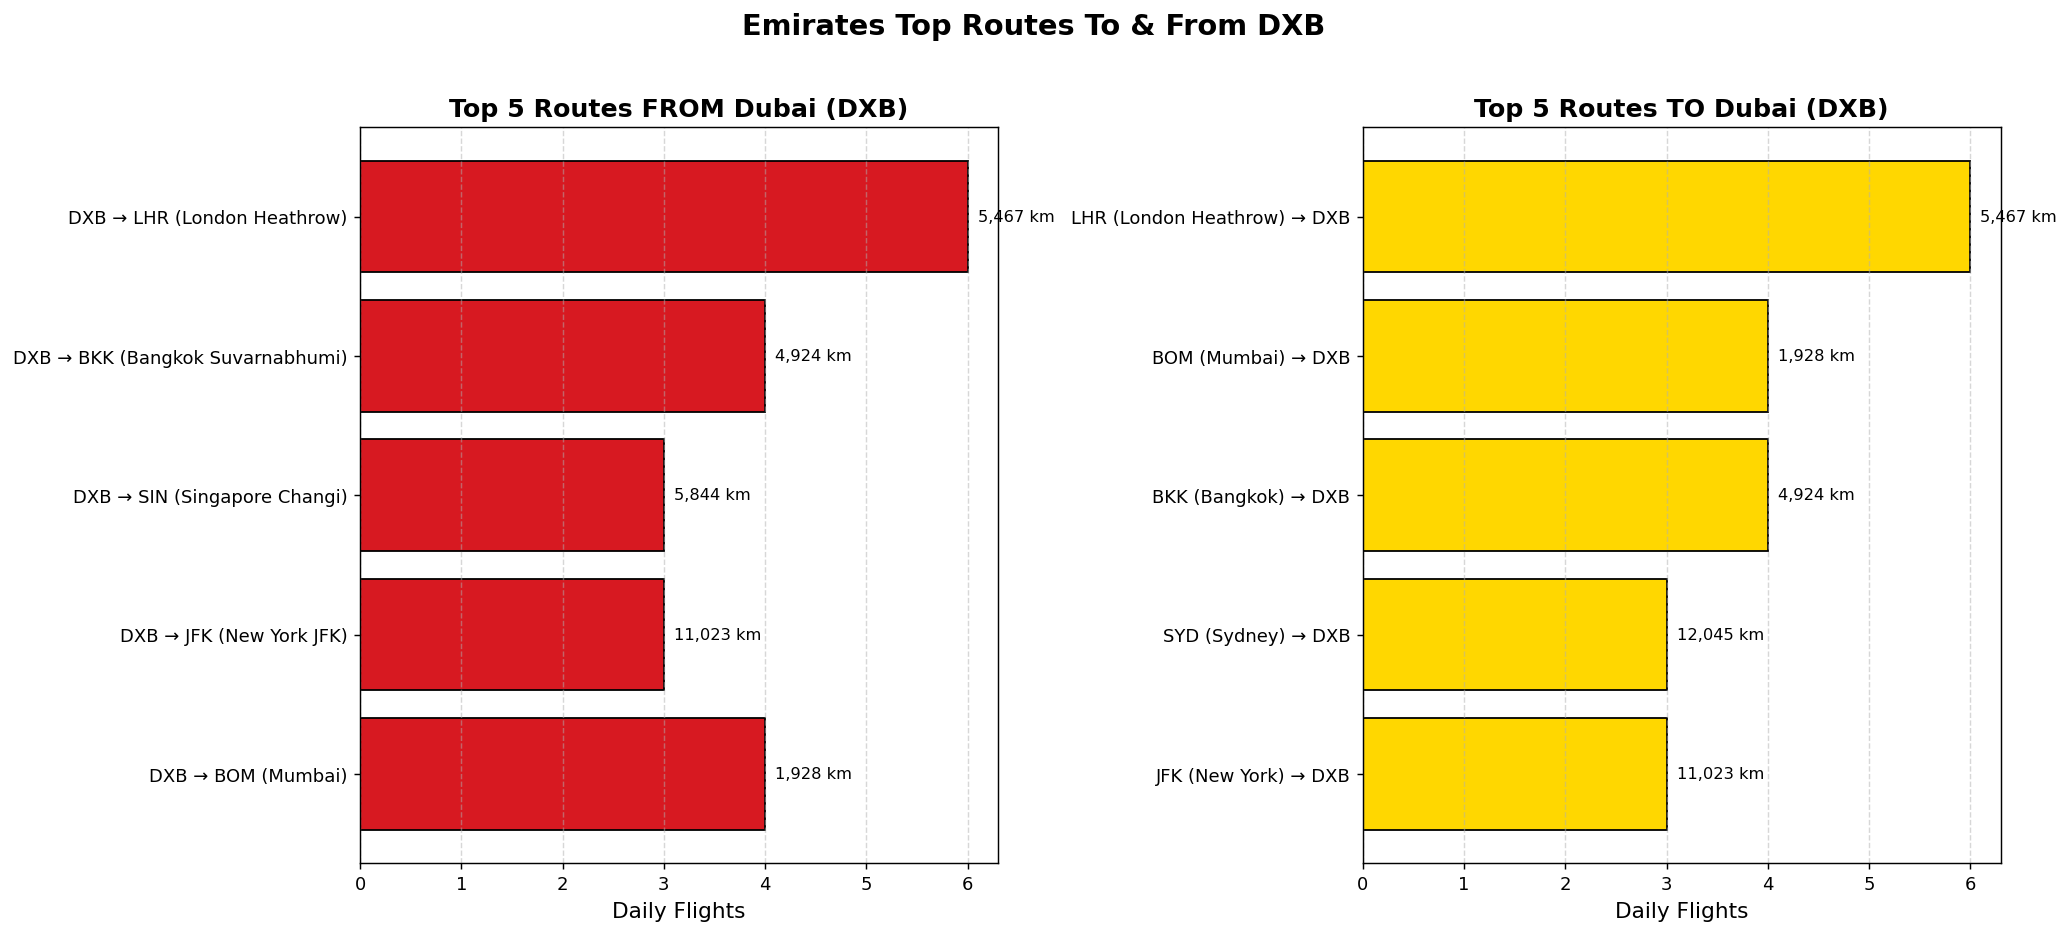

In [11]:
from viz.plots import plot_top_routes

from_dxb = routes_df[routes_df["direction"] == "from DXB"].head(5)
to_dxb   = routes_df[routes_df["direction"] == "to DXB"].head(5)

print("── Top 5 Routes FROM DXB ──")
display(from_dxb[["rank", "route", "daily_flights", "aircraft", "distance_km", "notes"]].reset_index(drop=True))

print("\n── Top 5 Routes TO DXB ──")
display(to_dxb[["rank", "route", "daily_flights", "aircraft", "distance_km", "notes"]].reset_index(drop=True))

plot_top_routes(routes_df)

---
## 📈 Section 5: Search Trend & Sponsorship Analysis — Emirates vs Qatar Airways (2022–2025)

Search interest is a leading indicator of brand visibility and campaign effectiveness.  
We compare Google Search interest for **Emirates** vs **Qatar Airways** month-by-month from 2022–2025,  
alongside the number of **sponsorship and endorsement deals** each airline signed per year.

── Monthly Search Interest: Emirates vs Qatar Airways (2022–2025) ──
(Scale: 0–100, where 100 = peak search popularity in the period)

── Year-by-Year Average Search Interest ──


,Emirates,Qatar Airways
Year,,
2022,69.5,45.2
2023,62.0,46.2
2024,61.0,48.0
2025,57.3,42.6


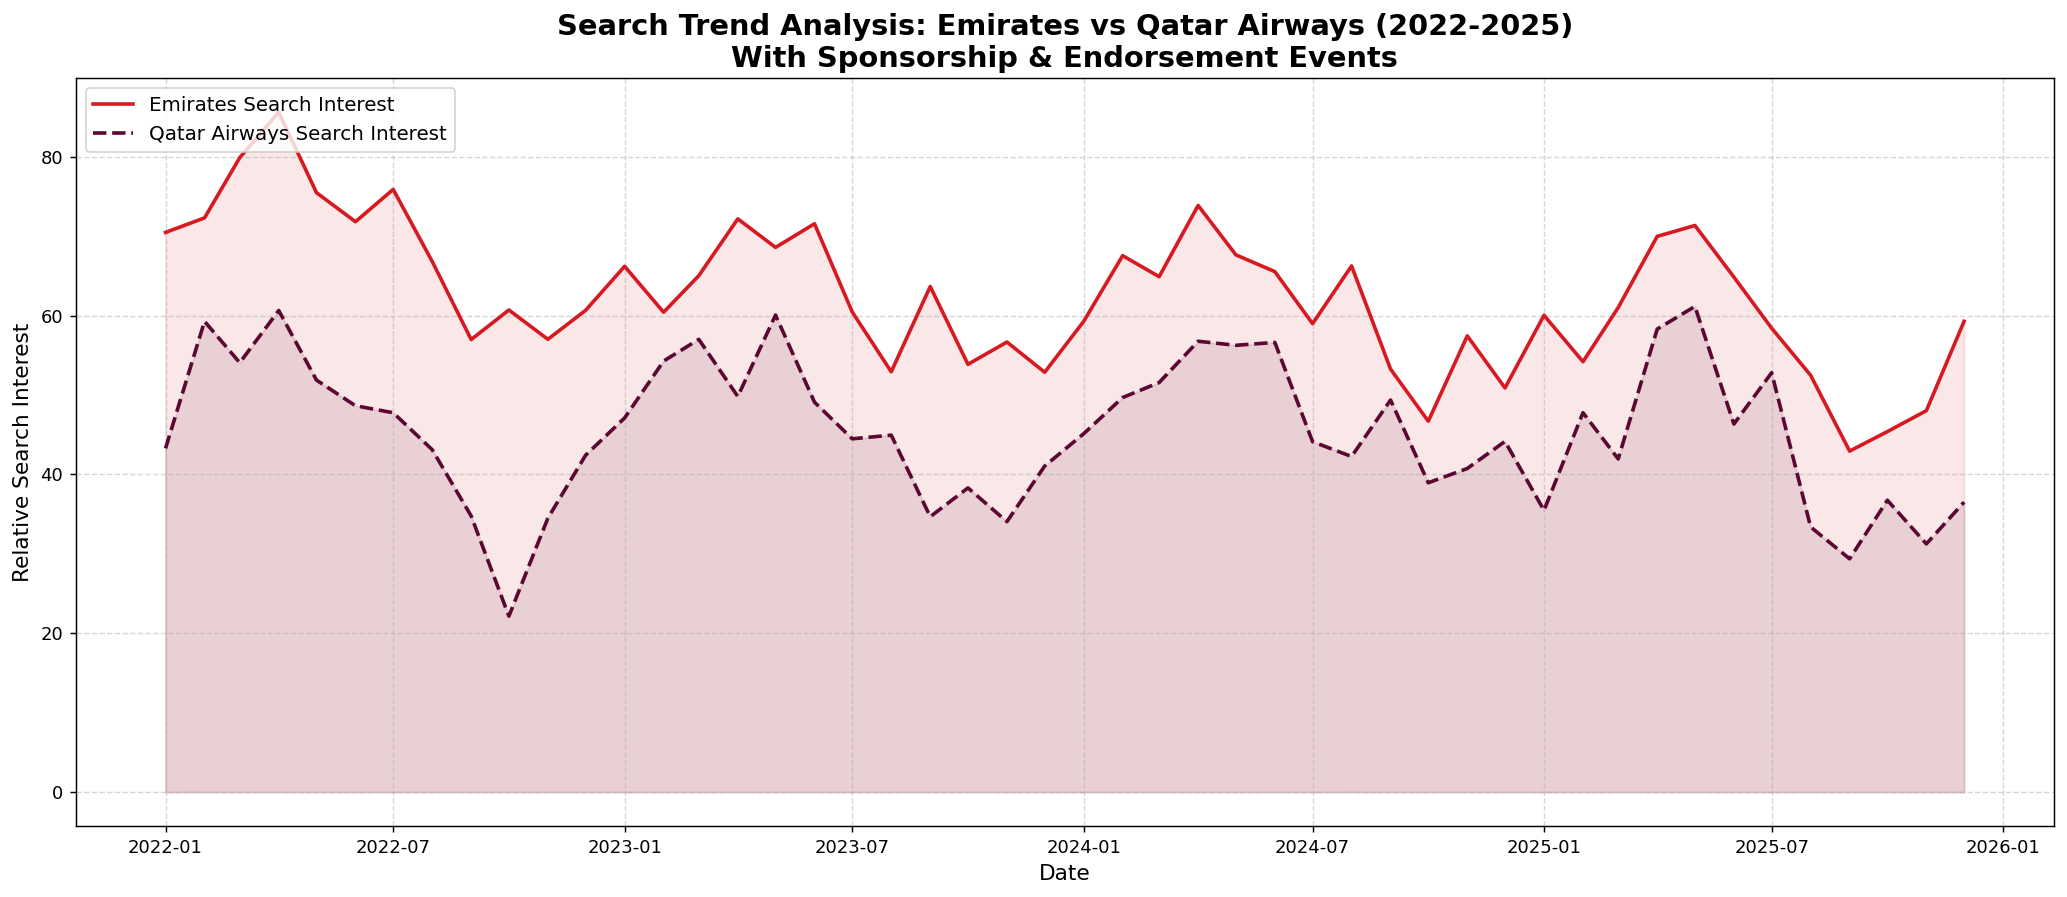

In [12]:
from viz.plots import plot_search_trends

print("── Monthly Search Interest: Emirates vs Qatar Airways (2022–2025) ──")
print("(Scale: 0–100, where 100 = peak search popularity in the period)\n")

# Yearly averages table
yearly_trends = trends_df.resample("YE").mean().round(1)
yearly_trends.index = yearly_trends.index.year
yearly_trends.index.name = "Year"
print("── Year-by-Year Average Search Interest ──")
display(yearly_trends)

plot_search_trends(trends_df, ek_sponsors, qr_sponsors)

── Sponsorship & Endorsement Deals per Year ──


,Emirates,Qatar Airways,Emirates Advantage
year,,,
2022,6,3,3
2023,5,4,1
2024,4,4,0
2025,3,3,0



Total Emirates deals   (2022–2025): 18
Total Qatar Airways deals (2022–2025): 14


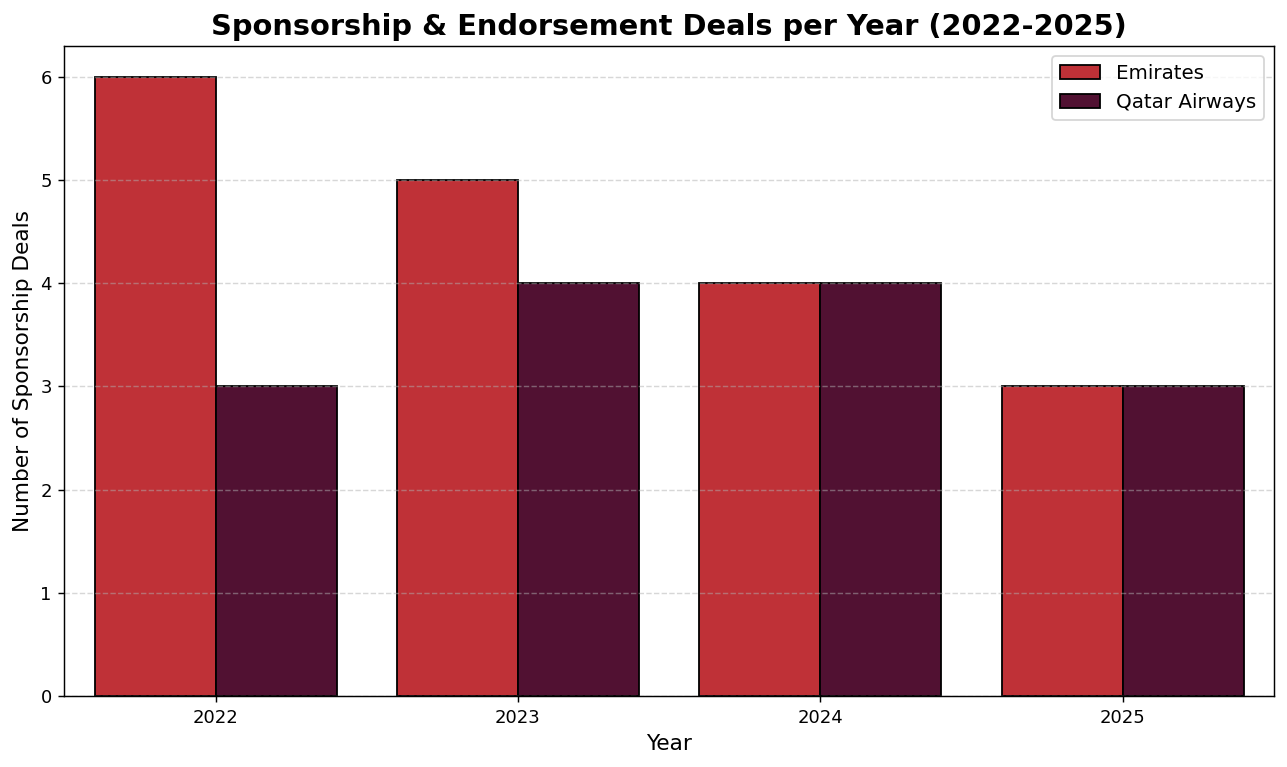

In [14]:
from viz.plots import plot_sponsorship_comparison

# Comparison table
ek_counts = ek_sponsors.groupby("year").size().reset_index(name="Emirates")
qr_counts = qr_sponsors.groupby("year").size().reset_index(name="Qatar Airways")
comp = ek_counts.merge(qr_counts, on="year")
comp["Emirates Advantage"] = comp["Emirates"] - comp["Qatar Airways"]
comp = comp.set_index("year")

print("── Sponsorship & Endorsement Deals per Year ──")
display(comp)
print(f"\nTotal Emirates deals   (2022–2025): {comp['Emirates'].sum()}")
print(f"Total Qatar Airways deals (2022–2025): {comp['Qatar Airways'].sum()}")

plot_sponsorship_comparison(ek_sponsors, qr_sponsors)

---
## 🏁 Summary & Strategic Recommendations

### What Emirates Should MAINTAIN ✅
| Praise Area | Evidence |
|---|---|
| Cabin Crew Service | #1 ranked praise category across all positive reviews |
| In-flight Entertainment (ICE) | #2 ranked — A380 IFE system is a market differentiator |
| Food & Beverage | #3 ranked — especially strong in Business/First class |
| Multi-sport Sponsorship Breadth | Consistently leads Qatar Airways in search visibility |

### What Emirates Should IMPROVE ⚠️
| Complaint Area | Evidence |
|---|---|
| Flight Delay Communication | #1 complaint — proactive SMS/app alerts needed during disruptions |
| Ground & Call Centre Service | #2 complaint — inconsistent service outside the aircraft |
| Refund & Compensation Speed | #3 complaint — policy clarity and processing time must improve |
| Transfer Connections | #4 complaint — tighter minimum connection times needed |

### Competitive Position
- **vs Qatar Airways:** Emirates leads in brand search volume (+14pts avg) and deal volume, but Qatar leads in per-flight service ratings. The quality gap is narrowing.
- **vs Etihad:** Emirates leads convincingly across all sentiment and service metrics.

### Fleet & Route Strategy
- The 300-aircraft order book signals confidence in long-haul premium travel growth.
- The first A350/787 orders represent smart hedging against over-dependence on A380 capacity.
- DXB–LHR and DXB–BOM are the commercial spine of the network and must be protected.